# Retail Store Sales Analysis

This project analyses retail transaction data to identify sales patterns, compare customer purchasing behaviour and build a machine-learning model.

In [62]:
%pip install pandas
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


## 1. Data Loading and Initial Exploration

In [63]:
df = pd.read_csv("retail_store_sales.csv")

The dataset was loaded into a Pandas DataFrame. The following checks examine its structure, numerical summary, missing values and duplicate records.

In [64]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [65]:
%pip install pandas matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.


In [66]:
df.shape

(12575, 11)

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [68]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


### Initial Observations

The dataset contains 12,575 rows and 11 columns. There are no duplicated records. Missing values were identified in Item, Price Per Unit, Quantity, Total Spent and Discount Applied.

Prices range from £5 to £41, while transaction totals range from £5 to £410. The average transaction value is approximately £129.65.

In [69]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df.columns.tolist()

['Transaction ID',
 'Customer ID',
 'Category',
 'Item',
 'Price Per Unit',
 'Quantity',
 'Total Spent',
 'Payment Method',
 'Location',
 'Transaction Date',
 'Discount Applied']

## 2. Data Cleaning and Transformation

A copy of the original DataFrame was created before cleaning. Missing prices were calculated using total spending and quantity. Rows without quantity and total-spending values were removed because these values could not be recovered reliably. Missing item and discount values were labelled as unknown, and transaction dates were converted into the datetime format.

In [72]:
df_clean = df.copy()

In [73]:
df_clean["Price Per Unit"] = df_clean["Price Per Unit"].fillna(
    df_clean["Total Spent"] / df_clean["Quantity"]
)

In [74]:
df_clean = df_clean.dropna(subset=["Quantity", "Total Spent"])

In [75]:
df_clean["Item"] = df_clean["Item"].fillna("Unknown")


In [76]:
df_clean["Discount Applied"] = (
    df_clean["Discount Applied"]
    .map({True: "Yes", False: "No"})
    .fillna("Unknown")
)

In [77]:
df_clean["Transaction Date"] = pd.to_datetime(
    df_clean["Transaction Date"]
)

In [78]:
df_clean.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

In [79]:
df_clean.shape


(11971, 11)

In [80]:
df_clean.to_csv("cleaned_retail_store_sales.csv", index=False)

## 3. Analysis Questions and Hypotheses

### 1. Sales by Product Category

**Question:** Which product category generates the highest total sales revenue?

**Hypothesis:** Electric household essentials generate the highest revenue because these products generally have higher prices.

### 2. Online and In-Store Sales

**Question:** Do online transactions generate more total revenue than in-store transactions?

**Hypothesis:** Online transactions generate more revenue than in-store transactions.

### 3. Payment Methods

**Question:** Which payment method has the highest average transaction value?

**Hypothesis:** Credit-card transactions have a higher average value than cash and digital-wallet transactions.

### 4. Discounts and Customer Spending

**Question:** Do transactions with a discount have a higher average total spend than transactions without a discount?

**Hypothesis:** Discounted transactions have a higher average total spend because discounts may encourage customers to purchase more.

### 5. Sales Over Time

**Question:** How did monthly sales revenue change between 2022 and 2025?

**Hypothesis:** Monthly sales revenue increased over time.

## 4. Exploratory Data Analysis and Visualisations

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Visualisation 1: Total Revenue by Product Category

This visualisation investigates which product category generated the highest total sales revenue.

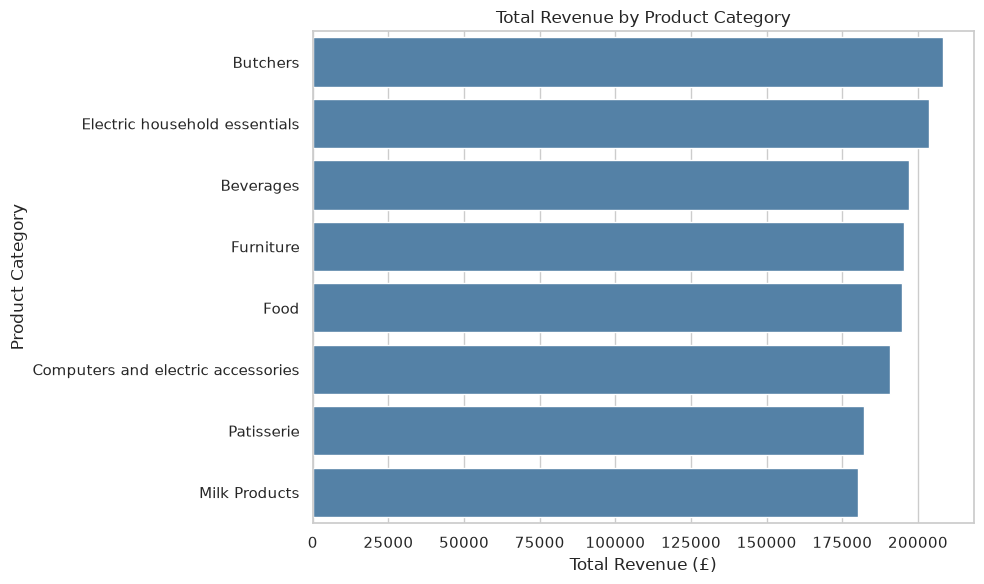

In [82]:
revenue_by_category = (
    df_clean.groupby("Category")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=revenue_by_category,
    x="Total Spent",
    y="Category",
    color="steelblue"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [83]:
revenue_by_category

,Category,Total Spent
0,Butchers,208118.0
1,Electric household essentials,203813.5
2,Beverages,197047.5
3,Furniture,195310.0
4,Food,194812.0
5,Computers and electric accessories,190692.5
6,Patisserie,182165.5
7,Milk Products,180112.0


#### Insight

The Butchers category generated the highest total revenue at approximately £208,118. Electric household essentials generated the second-highest revenue at approximately £203,814.

This result contradicts the original hypothesis that electric household essentials would generate the highest revenue. Although electrical household products may have relatively high prices, the Butchers category produced the greatest overall revenue.

### Visualisation 2: Total Revenue by Location

This visualisation compares the total revenue generated by online and in-store transactions.

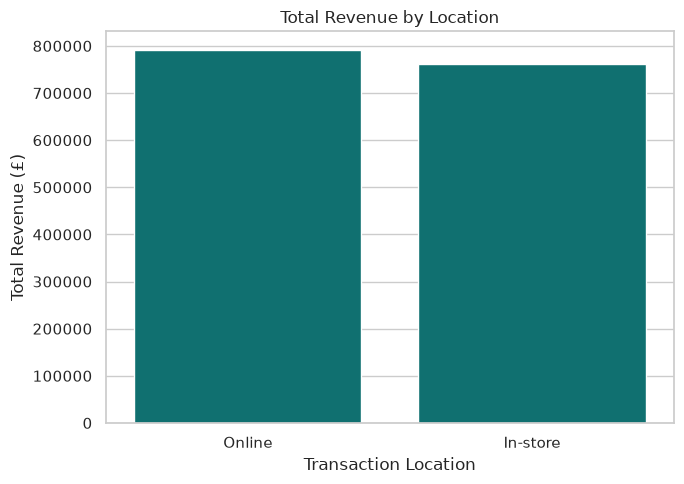

In [84]:
revenue_by_location = (
    df_clean.groupby("Location")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=revenue_by_location,
    x="Location",
    y="Total Spent",
    color="teal"
)

plt.title("Total Revenue by Location")
plt.xlabel("Transaction Location")
plt.ylabel("Total Revenue (£)")
plt.tight_layout()
plt.show()

In [85]:
revenue_by_location

,Location,Total Spent
0,Online,791401.0
1,In-store,760670.0


#### Insight

Online transactions generated approximately £791,401 in total revenue, compared with approximately £760,670 from in-store transactions.

The result supports the hypothesis that online transactions generate more total revenue than in-store transactions. However, the difference is relatively small, suggesting that both locations make an important contribution to overall sales.

### Visualisation 3: Average Transaction Value by Payment Method

This visualisation compares the average amount spent using each payment method.

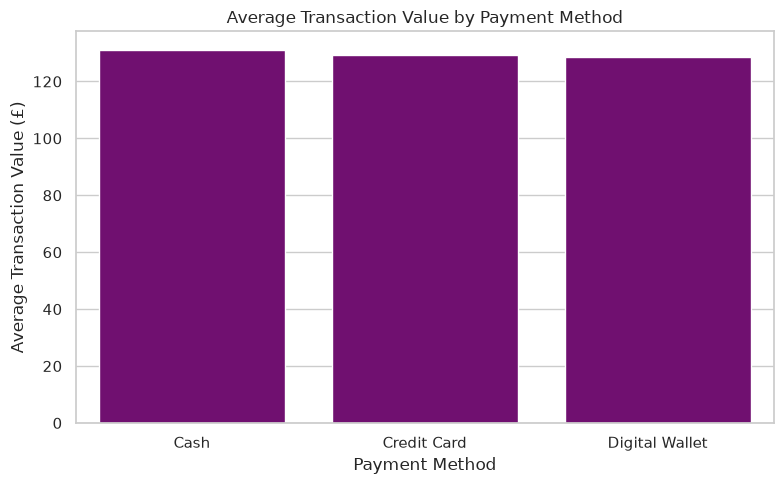

In [86]:
average_spend_by_payment = (
    df_clean.groupby("Payment Method")["Total Spent"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=average_spend_by_payment,
    x="Payment Method",
    y="Total Spent",
    color="purple"
)

plt.title("Average Transaction Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Transaction Value (£)")
plt.tight_layout()
plt.show()

In [87]:
average_spend_by_payment

,Payment Method,Total Spent
0,Cash,131.052888
1,Credit Card,129.127069
2,Digital Wallet,128.718346


#### Insight

Cash transactions had the highest average transaction value at approximately £131.05. Credit-card transactions averaged approximately £129.13, while digital-wallet transactions averaged approximately £128.72.

This result contradicts the hypothesis that credit-card transactions would have the highest average value. However, the differences between the three payment methods are small, suggesting that payment method has little effect on the amount spent.

### Visualisation 4: Transaction Spending by Discount Status

This visualisation investigates whether customers spend more when a discount is applied. Transactions with an unknown discount status are excluded from this comparison.

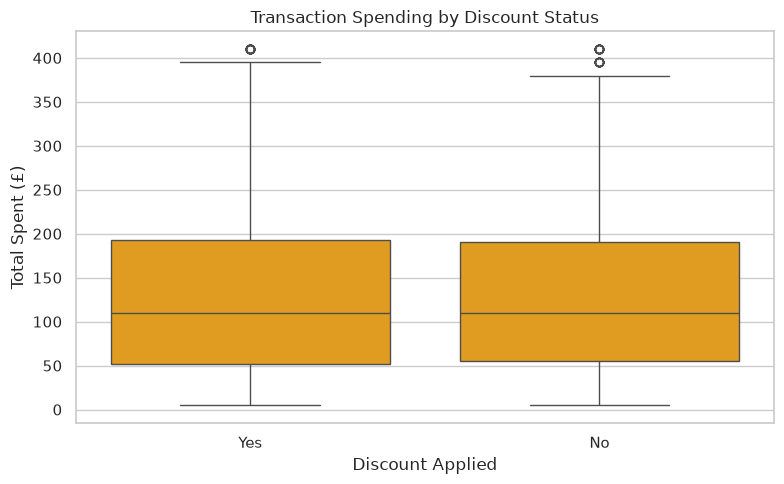

In [88]:
known_discounts = df_clean[
    df_clean["Discount Applied"].isin(["Yes", "No"])
]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=known_discounts,
    x="Discount Applied",
    y="Total Spent",
    color="orange"
)

plt.title("Transaction Spending by Discount Status")
plt.xlabel("Discount Applied")
plt.ylabel("Total Spent (£)")
plt.tight_layout()
plt.show()

In [89]:
average_spend_by_discount = (
    known_discounts.groupby("Discount Applied")["Total Spent"]
    .mean()
    .round(2)
)

average_spend_by_discount

Discount Applied
No     129.95
Yes    130.49
Name: Total Spent, dtype: float64

#### Insight

Transactions with a discount had an average total spend of approximately £130.49, compared with approximately £129.95 for transactions without a discount.

The result slightly supports the hypothesis that discounts encourage higher spending. However, the difference is only approximately £0.54, so the practical effect of discounts on transaction value appears to be very small.

### Visualisation 5: Monthly Sales Revenue Over Time

This visualisation examines how total monthly sales revenue changed between January 2022 and January 2025.

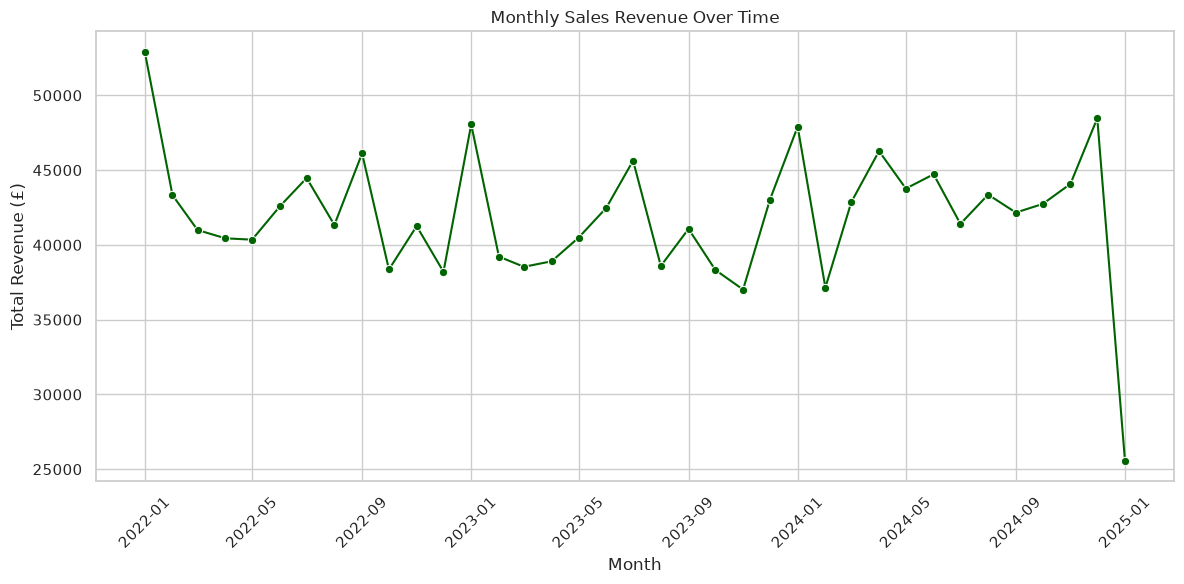

In [90]:
monthly_sales = (
    df_clean.set_index("Transaction Date")
    .resample("MS")["Total Spent"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Transaction Date",
    y="Total Spent",
    marker="o",
    color="darkgreen"
)

plt.title("Monthly Sales Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [91]:
annual_sales = (
    df_clean.groupby(df_clean["Transaction Date"].dt.year)["Total Spent"]
    .sum()
    .round(2)
)

annual_sales

Transaction Date
2022    510329.5
2023    491312.0
2024    524881.0
2025     25548.5
Name: Total Spent, dtype: float64

#### Insight

Monthly sales fluctuated throughout the dataset rather than showing continuous growth. Total revenue was approximately £510,330 in 2022, £491,312 in 2023 and £524,881 in 2024.

Revenue decreased between 2022 and 2023 before increasing to its highest annual level in 2024. Therefore, the hypothesis that sales consistently increased over time is not clearly supported.

The January 2025 result should not be compared directly with complete years because the dataset only contains transactions up to 18 January 2025.